In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from sklearn.preprocessing import MinMaxScaler

In [2]:
def save_edges_and_weights(save_dir, edges, weights, train_size, normalization):
    # Normalize 会让本来没有0的数据集产生零，即本来的最小值会变成0
    save_dir = Path(save_dir)
    nums_type = edges.max(0) + 1

    weights = weights.reshape(-1, 1)

    if normalization:
        scaler = MinMaxScaler()
        weights = scaler.fit_transform(weights)
        print('Normalize', scaler)

    train_data, test_data, train_weight, test_weight = train_test_split(edges, weights, train_size=train_size)
    train_weight = train_weight.reshape(-1)
    test_weight = test_weight.reshape(-1)

    np.savez(save_dir / 'train_data.npz', train_data=train_data, train_weight=train_weight,
             nums_type=nums_type)
    np.savez(save_dir / 'test_data.npz', test_data=test_data, test_weight=test_weight,
             nums_type=nums_type)


def save_metadata(save_dir, edges, train_size, nums_type, normalization):
    metadata = dict(
        train_size=train_size,
        normalization=normalization,
        num_edges=edges.shape[0],
        num_nodes=sum(nums_type),
        num_cells=nums_type[0],
        num_genes=nums_type[1],
        num_omics=nums_type[2],
    )
    np.savez(save_dir / 'metadata', **metadata)


In [12]:
from examples.case_studies.scNMT_analysis import load_data

expression_data, promoter_methy_data, promoter_acc_data, labels = load_data()

In [13]:
len(labels)

1940

<Axes: >

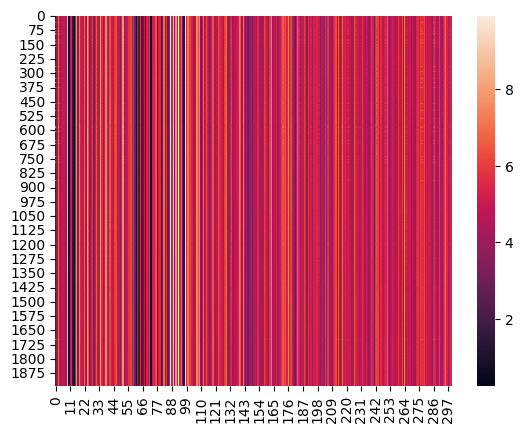

In [5]:
sns.heatmap(expression_data)

<Axes: >

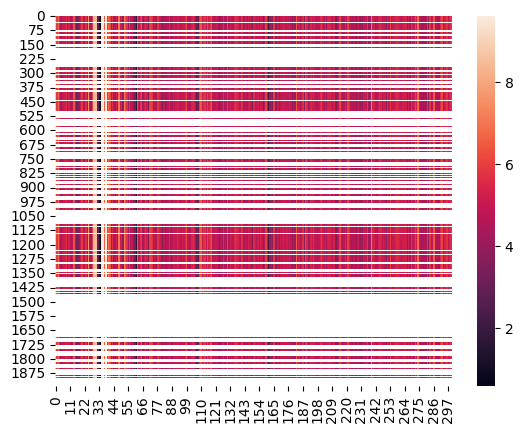

In [14]:
sns.heatmap(promoter_methy_data)

<Axes: >

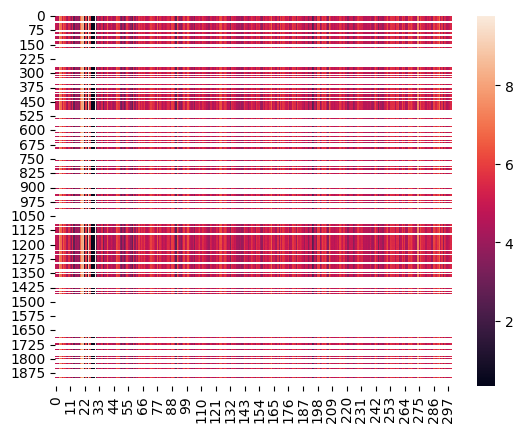

In [15]:
sns.heatmap(promoter_acc_data)

In [6]:
def remove_all_nan_columns(data, sigma=1):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])
    data = np.exp(data / sigma)
    return data

In [9]:
expression_data.shape, promoter_methy_data.shape,promoter_acc_data.shape

((1940, 300), (1940, 300), (1940, 300))

In [10]:
expression_data_clean = remove_all_nan_columns(expression_data, sigma=10)
promoter_methy_data_clean = remove_all_nan_columns(promoter_methy_data, sigma=10)
promoter_acc_data_clean = remove_all_nan_columns(promoter_acc_data, sigma=10)

Input #cols 300
After remove all nan 300
Input #cols 300
After remove all nan 0
Input #cols 300
After remove all nan 0


Text(0.5, 1.0, 'methylation_data_clean')

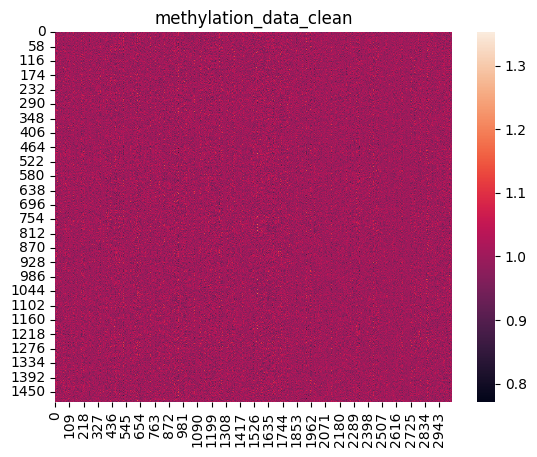

In [ ]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

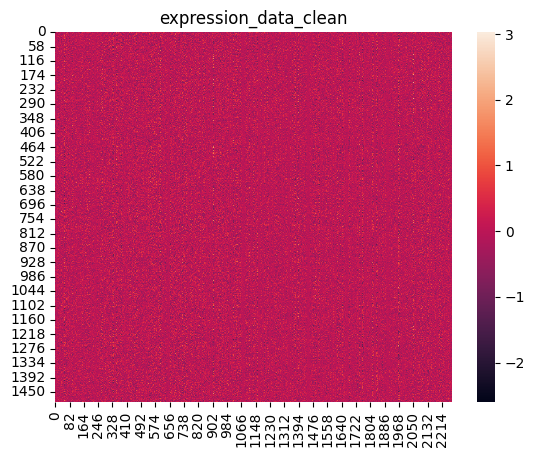

In [ ]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [ ]:
expression_data_clean.min(), expression_data_clean.max()

(0.771323157351455, 1.3534537319723328)

In [ ]:
methylation_data_clean.min(), methylation_data_clean.max()

(0.771278439105178, 1.3527285310258725)

In [ ]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(data)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [ ]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [ ]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((3385280, 3), (3385280,), (4532580, 3), (4532580,))

In [ ]:
expression_edges.max(0), methylation_edges.max(0)

(array([1489, 2271,    0]), array([1489, 5313,    1]))

In [ ]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [ ]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [ ]:
edges.shape, weights.shape

((7917860, 3), (7917860,))

In [ ]:
np.any(weights == 0)

False

In [ ]:
save_edges_and_weights('./data/scNMT', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [ ]:
train_data = np.load('./data/scNMT/train_data.npz', allow_pickle=True)
test_data = np.load('./data/scNMT/test_data.npz', allow_pickle=True)

In [ ]:
np.any(train_data['train_weight'] == 0)

False

In [ ]:
np.any(test_data['test_weight'] == 0)

False

In [ ]:
train_data['nums_type']

array([1490, 5314,    2])

In [ ]:
!python hgnn/main_torch.py --data scNMT --feature adj --loss bce --iter 50 --batch_size 256

1.0 -0.5
model_no_randomwalk
Use train_weight
Node type num [1490 5314    2]
H.shape [(1490, 6334288), (5314, 6334288), (2, 6334288)]
embeddings.shape [(1490, 6806), (5314, 6806), (2, 6806)]
embeddings_initial [False, False, False]
[1.0191493 1.0372508 1.0428331 ... 1.0040718 1.0152127 1.0383822] 0.77127844 1.3534538
walk type 
adding pad idx
dict_size 6334288 7917860
train data amount 6334288
64
tensor([   0, 1490, 6804, 6806], device='cuda:0')
w.shape (1490, 5316)
(1490, 5316)
w.shape (5314, 1492)
(5314, 1492)
w.shape (2, 6804)
(2, 6804)
self.input_size [5316, 1492, 6804]
inp 5316 out 64 weight.shape torch.Size([64, 5316])
fan_in 5316 72.91090453423274
inp 1492 out 64 weight.shape torch.Size([64, 1492])
fan_in 1492 38.62641583165593
inp 6804 out 64 weight.shape torch.Size([64, 6804])
fan_in 6804 82.48636250920512
save embeddings
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 M

In [ ]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 373K Nov 10 13:17 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 373K Nov 10 13:17 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs 1.3M Nov 10 13:17 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs 1.3M Nov 10 13:17 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 13:17 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs  640 Nov 10 13:17 ./mymodel_2_origin.npy
-rw-r--r-- 1 congfeng4 mscs  92K Nov 10 11:39 ./PEA_STA_wv_64_.npy


In [ ]:
!mkdir -p ./embeddings/hgnn/scNMT

In [ ]:
!mv *.npy ./embeddings/hgnn/scNMT

In [ ]:
cell_embeddings = np.load('./embeddings/hgnn/scNMT/mymodel_0.npy', allow_pickle=True)

In [ ]:
cell_embeddings.shape

(1490, 64)

/public/congfeng4/miniconda3/envs/py39/lib/python3.9/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


{'NMI': 0.0, 'ARI': 0.0, 'FMI': 0.7814893694215619}

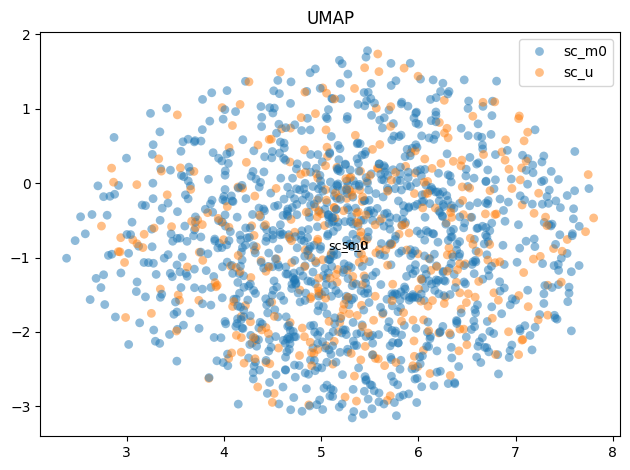

In [ ]:
umap_visualize(cell_embeddings, labels[1:])